Shape: (70000, 784)


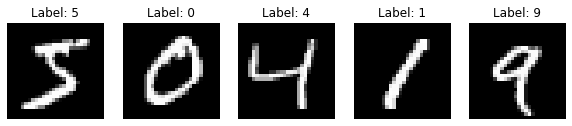

Accuracy: 0.8955


c:\Users\asus\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


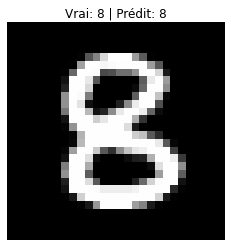


Conclusion:
- On a chargé des images
- On a entraîné un modèle
- On a fait des prédictions
- On a visualisé les résultats


In [ ]:
# Demo scikit-learn — Classification avec MNIST

# 1. Imports
# "On commence par importer les bibliothèques nécessaires"
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

#bon modèle
from sklearn.ensemble import RandomForestClassifier

#mauvais modèle
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# 2. Charger les données
# "On charge le dataset MNIST, qui contient des images de chiffres manuscrits"
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data
y = mnist.target.astype(int)

# "Chaque image est un tableau de 784 pixels (28x28)"
print("Shape:", X.shape)

# 3. Afficher quelques images
# "On va afficher quelques exemples pour voir à quoi ressemblent les données"
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")
plt.show()

# 4. Réduire le dataset (pour aller plus vite en démo)
#X_small = X[:2000]
#y_small = y[:2000]

#"Pour aller plus vite, on ne prend qu'un sous-ensemble des données"
X_small = X[:10000]
y_small = y[:10000]

# 5. Train / Test split
# "On sépare les données en entraînement et test"
X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small, test_size=0.2, random_state=42
)

# 6. Choix du Modèle  ( bon modèle )

# On essaie vaec un mauvais modèle
model = LogisticRegression(max_iter=100)

# "On utilise un Random Forest pour classifier les chiffres (bon modèle)"
## model = RandomForestClassifier(n_estimators=50, random_state=42)

# "Le modèle apprend"
model.fit(X_train, y_train)

# 7. Prédictions
# "On fait des prédictions sur le jeu de test"
y_pred = model.predict(X_test)

# "On calcule l'accuracy"
print("Accuracy:", accuracy_score(y_test, y_pred))

# 8. Démo visuelle (prédiction sur une image)
# "On va regarder une image et voir ce que le modèle prédit"
index = 1
image = X_test[index]
true_label = y_test[index]
predicted_label = model.predict([image])[0]

plt.imshow(image.reshape(28, 28), cmap="gray")
plt.title(f"Vrai: {true_label} | Prédit: {predicted_label}")
plt.axis("off")
plt.show()

# 9. Conclusion
# "Conclusion : le modèle est capable de reconnaître des chiffres manuscrits"
print("\nConclusion:")
print("- On a chargé des images")
print("- On a entraîné un modèle")
print("- On a fait des prédictions")
print("- On a visualisé les résultats")
